## Config

In [31]:
from pathlib import Path

ROOT = Path("/home/liang/workdir/NCKU-ML-25Fall/Final_Project") 


RAW_POSITIVE_IMAGES_ROOT = ROOT / "raw"/"positive"
RAW_NEGATIVE_IMAGES_ROOT = ROOT / "raw"/"negative"

TILE_SIZE = 128
OVERLAP_RATIO = 0.1
DATASET_POSITIVE_TILED_DIR = ROOT / f"dataset_tiled_{TILE_SIZE}/positive"
DATASET_NEGATIVE_TILED_DIR = ROOT / f"dataset_tiled_{TILE_SIZE}/negative"

SLICE_HEIGHT=128
SLICE_WIDTH=128
OVERLAP_RATIO = 0.5


## Color Normalization

In [27]:
"""
Stain Normalization using Macenko method
"""
import numpy as np
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
import traceback

class MacenkoNormalizer:
    def __init__(self):
        self.HERef = np.array([[0.5626, 0.2159],
                               [0.7201, 0.8012],
                               [0.4062, 0.5581]])
        self.maxCRef = np.array([1.9705, 1.0308])
        
    def __convert_rgb_to_od(self, img):
        # Avoid zero division or log of zero
        mask = (img == 0)
        img[mask] = 1
        img = img.astype(np.float64) + 1
        return -np.log(img / 256)
    
    def __convert_od_to_rgb(self, od):
        # Clip values to avoid overflow in exp
        od = np.clip(od, -10, 10)
        return (256 * np.exp(-od) - 1).astype(np.uint8)
    
    def __find_he_components(self, od, percentile=99):
        od_hat = od[~np.any(od < 0.15, axis=1)]
        if od_hat.shape[0] < 10:
            return None
        
        try:
            _, _, V = np.linalg.svd(od_hat, full_matrices=False)
        except np.linalg.LinAlgError:
            return None
            
        plane = V[:2, :].T
        proj = np.dot(od_hat, plane)
        
        phi = np.arctan2(proj[:, 1], proj[:, 0])
        min_phi = np.percentile(phi, 100 - percentile)
        max_phi = np.percentile(phi, percentile)
        
        v1 = np.array([np.cos(min_phi), np.sin(min_phi)])
        v2 = np.array([np.cos(max_phi), np.sin(max_phi)])
        he = np.array([np.dot(plane, v1), np.dot(plane, v2)]).T
        
        if he[0, 0] < he[0, 1]:
            he = he[:, [1, 0]]
        return he
    
    def fit(self, target_img):
        try:
            img = np.array(target_img)
            if img.ndim < 3 or img.shape[2] < 3:
                 return False
            od = self.__convert_rgb_to_od(img.reshape(-1, 3))
            he = self.__find_he_components(od)
            if he is None:
                return False
            self.HERef = he
            y = np.linalg.lstsq(he, od.T, rcond=None)[0]
            self.maxCRef = np.percentile(y, 99, axis=1)
            return True
        except Exception:
            return False
    
    def transform(self, source_img):
        try:
            img = np.array(source_img)
            if img.ndim < 3 or img.shape[2] < 3:
                 return source_img
            h, w, _ = img.shape
            od = self.__convert_rgb_to_od(img.reshape(-1, 3))
            he = self.__find_he_components(od)
            if he is None:
                return source_img
            
            y = np.linalg.lstsq(he, od.T, rcond=None)[0]
            max_c = np.percentile(y, 99, axis=1, keepdims=True)
            if np.any(max_c == 0):
                 max_c[max_c == 0] = 1
            
            y = y / max_c * self.maxCRef[:, np.newaxis]
            
            od_normalized = np.dot(self.HERef, y).T
            img_normalized = self.__convert_od_to_rgb(od_normalized)
            return Image.fromarray(img_normalized.reshape(h, w, 3))
        except Exception as e:
            print(f"Normalization failed: {e}")
            return source_img


def normalize_dataset(source_dir, target_dir, normalizer):
    source_path = Path(source_dir)
    target_path = Path(target_dir)
    target_path.mkdir(parents=True, exist_ok=True)
    
    valid_exts = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
    image_files = [f for f in source_path.iterdir() 
                   if f.is_file() and f.suffix.lower() in valid_exts]
    
    print(f"Found {len(image_files)} images to normalize")
    
    failed_count = 0
    
    for img_file in tqdm(image_files, desc="Normalizing"):
        try:
            with Image.open(img_file) as img_raw:
                img = img_raw.convert('RGB')
                normalized = normalizer.transform(img)
                normalized.save(target_path / img_file.name)
        except (UnidentifiedImageError, OSError) as e:
            print(f"Error reading {img_file.name}: {e}. Skipping.")
            failed_count += 1
        except Exception as e:
            print(f"Warning: {img_file.name} failed ({e}), attempting to copy original...")
            try:
                with Image.open(img_file) as img_raw:
                    img_raw.convert('RGB').save(target_path / img_file.name)
            except Exception as e2:
                print(f"CRITICAL: Could not even copy original {img_file.name}: {e2}")
                failed_count += 1
    
    if failed_count > 0:
        print(f"\nCompleted with {failed_count} failures.")

In [6]:
# 選第一張 positive 當 reference
try:
    ref_candidates = list((ROOT / "raw/positive").glob("*.png"))
    if not ref_candidates:
        raise FileNotFoundError("No reference image found")
    ref_path = ref_candidates[0]
    print(f"Reference: {ref_path}")

    normalizer = MacenkoNormalizer()
    ref_img = Image.open(ref_path).convert('RGB')
    if normalizer.fit(ref_img):
        print("\n[1/2] Normalizing POSITIVE...")
        normalize_dataset(ROOT / "raw/positive", ROOT / "raw_normalized/positive", normalizer)

        print("\n[2/2] Normalizing NEGATIVE...")
        normalize_dataset(ROOT / "raw/negative", ROOT / "raw_normalized/negative", normalizer)
    else:
        print("Failed to fit normalizer on reference image.")

    print("\nDone!")
except Exception as e:
    print(f"Global Error: {e}")

Reference: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/raw/positive/3.png

[1/2] Normalizing POSITIVE...
Found 503 images to normalize


Normalizing: 100%|██████████| 503/503 [24:46<00:00,  2.95s/it]



[2/2] Normalizing NEGATIVE...
Found 545 images to normalize


Normalizing: 100%|██████████| 545/545 [26:46<00:00,  2.95s/it]


Done!


In [7]:
RAW_POSITIVE_IMAGES_ROOT = ROOT / "raw_normalized"/"positive"
RAW_NEGATIVE_IMAGES_ROOT = ROOT / "raw_normalized"/"negative"

## Slicing

In [32]:
from sahi.slicing import slice_image
from pathlib import Path
import pandas as pd
import os
import numpy as np
from PIL import Image
import cv2
import numpy as np
from PIL import Image
import time

def safe_open_image(file_path, max_retries=3, delay=0.1):
    """Safely open image with retries"""
    for attempt in range(max_retries):
        try:
            img = Image.open(file_path)
            img.load()  # Force load
            return img
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(delay)
            else:
                return None
    return None

def is_background_robust(image_pil, sat_thresh=15, area_thresh=0.1):
    """
    Robust background filtering based on HSV saturation.
    
    :param image_pil: PIL Image object
    :param sat_thresh: Saturation threshold (0~255) typically 15-20.
    :param area_thresh: Tissue area ratio (0.0 ~ 1.0).
    :return: True (is background/drop), False (is tissue/keep)
    """
    try:
        img_np = np.array(image_pil)
        hsv_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)
        s_channel = hsv_img[:, :, 1]
        tissue_mask = s_channel > sat_thresh
        tissue_ratio = np.count_nonzero(tissue_mask) / tissue_mask.size
        
        if tissue_ratio < area_thresh:
            return True
        else:
            return False
    except Exception as e:
        print(f"Error in background check: {e}")
        return True # Treat as background on error

def run_offline_slicing(source_img_dir, target_img_dir, split_name):
    print(f"Processing {split_name} split...")

    source_path = Path(source_img_dir)
    target_path = Path(target_img_dir)
    target_path.mkdir(parents=True, exist_ok=True)

    valid_extensions = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
    try:
        image_files = [f for f in source_path.iterdir() if f.is_file() and f.suffix.lower() in valid_extensions]
    except FileNotFoundError:
        print(f"Source directory not found: {source_path}")
        return
    
    print(f"Found {len(image_files)} images to slice")
    
    total_patches = 0
    dropped_patches = 0
    
    for idx, img_file in enumerate(image_files):
        bag_dir = target_path / img_file.stem
        bag_dir.mkdir(exist_ok=True)
        
        print(f"[{idx+1}/{len(image_files)}] Slicing: {img_file.name} -> {bag_dir}")

        try:
            slice_result = slice_image(
                image=str(img_file),
                output_dir=str(bag_dir),
                output_file_name=img_file.stem,
                slice_height=SLICE_HEIGHT,
                slice_width=SLICE_WIDTH,
                overlap_height_ratio=OVERLAP_RATIO,
                overlap_width_ratio=OVERLAP_RATIO,
                verbose=False
            )
        except Exception as e:
            print(f"Error slicing {img_file.name}: {e}")
            continue
        
        saved_files = sorted(list(bag_dir.glob("*.png")))
        metadata = []
        for file_path in saved_files:
            parts = file_path.stem.split('_')
            try:
                x = int(parts[-4])
                y = int(parts[-3])
            except (ValueError, IndexError):
                print(f"Warning: Cannot parse coordinates from {file_path.name}")
                continue

            img = safe_open_image(file_path)
            if img is None:
                print(f"Warning: Cannot open image {file_path}")
                try:
                    os.remove(file_path)
                except:
                    pass
                continue
            
            # Use opened image directly
            if is_background_robust(img):
                try:
                    os.remove(file_path)
                except:
                    pass
                dropped_patches += 1
                continue
            else:
                metadata.append({
                    "filename": file_path.name,
                    "x": x,
                    "y": y
                })
        num_slices = len(metadata)
        if num_slices > 0:
            df = pd.DataFrame(metadata)
            df.to_csv(bag_dir / "coords.csv", index=False)
        else:
            print(f"Warning: No valid patches for {img_file.name}")

        total_patches += num_slices

    print(f"Finished {split_name} split")
    print(f"Total sliced patches generated: {total_patches}")
    print(f"Dropped {dropped_patches} background patches")
    

# Execute
run_offline_slicing(str(RAW_POSITIVE_IMAGES_ROOT), str(DATASET_POSITIVE_TILED_DIR), "positive")
run_offline_slicing(str(RAW_NEGATIVE_IMAGES_ROOT), str(DATASET_NEGATIVE_TILED_DIR), "negative")

Processing positive split...
Found 503 images to slice
[1/503] Slicing: 3.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/positive/3
[2/503] Slicing: 86.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/positive/86
[3/503] Slicing: 14.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/positive/14
[4/503] Slicing: 175.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/positive/175
[5/503] Slicing: 236.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/positive/236
[6/503] Slicing: 272.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/positive/272
[7/503] Slicing: 110.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/positive/110
[8/503] Slicing: 312.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/positive/312
[9/503] Slicing: 28.png -> /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled

## Feature Extraction
### ViT v.s. ResNet
考慮到 MIL + 病理細胞的場合，ResNet 可能會比較好。ResNet 主要專注於紋理跟邊緣，ViT 則是看整體的，而病理細胞的特徵主要在於細胞的紋理和邊緣，因此 ResNet 可能會比較好。
且關注於整體的細節會在後續 MIL 當中去處理，因此這裡的 Feature Extraction 選擇 Resnet。
### Background
我會剔除空白圖片，因為空白圖片的數量會比想像中還多，不剔除會影響到後續的訓練，不管是表現或是訓練的速度都是。
而且當兩者我怕萬一有顏色的問題會導致 MIL 學習到顏色比紋理還重要的這種傾向，所以會剔除。

In [33]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from pathlib import Path
from PIL import Image
import os
from tqdm import tqdm # 進度條工具

In [34]:
# --- 設定參數 ---
BATCH_SIZE = 512   # 根據您的 GPU VRAM 調整 (ResNet18 很小，128~256 通常沒問題)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 8    # 讀取圖片的執行緒數量 (Windows 上如果報錯改為 0)

DATASET_TILED_POS = str(ROOT / "dataset_tiled_128/positive" )
DATASET_TILED_NEG = str(ROOT / "dataset_tiled_128/negative")

FEATURES_DIR_POS = str(ROOT /"dataset_tiled_128"/"features"/ "positive")
FEATURES_DIR_NEG = str(ROOT /"dataset_tiled_128"/"features"/"negative")

In [35]:
# ==========================================
# 1. Define simple Dataset (Read all patches in a bag)
# ==========================================
class BagDataset(Dataset):
    def __init__(self, bag_folder, transform=None):
        self.bag_folder = Path(bag_folder)
        self.transform = transform
        valid_exts = {'.png', '.jpg', '.jpeg'}
        self.files = []
        if self.bag_folder.exists():
            self.files = sorted([f for f in self.bag_folder.iterdir() if f.suffix.lower() in valid_exts])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        try:
            img = Image.open(img_path).convert('RGB') # Ensure RGB
            if self.transform:
                img = self.transform(img)
            return img
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return dummy black image
            dummy_img = Image.new('RGB', (224, 224), color='black')
            if self.transform:
                dummy_img = self.transform(dummy_img)
            return dummy_img


In [ ]:
# ==========================================
# 2. ResNet50
# ==========================================
def get_feature_extractor():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    model.fc = nn.Identity()
    
    model.to(DEVICE)
    model.eval()
    return model

In [ ]:
from torchvision import transforms
# ==========================================
# 3. Feature Extraction
# ==========================================
def run_feature_extraction(source_root, save_root):
    """
    source_root: 切好圖的資料夾根目錄 (例如: DATASET_TILED_DIR/positive)
    save_root:   特徵存檔的目錄 (例如: FEATURES_DIR/positive)
    """
    source_path = Path(source_root)
    save_path = Path(save_root)
    save_path.mkdir(parents=True, exist_ok=True)
    
    transform_with_aug = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=90),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    model = get_feature_extractor()
    
    bag_folders = [f for f in source_path.iterdir() if f.is_dir()]
    print(f"Found {len(bag_folders)} bags in {source_root}")

    for bag_folder in tqdm(bag_folders, desc="Extracting Features"):
        bag_name = bag_folder.name
        save_file = save_path / f"{bag_name}.pt"
        
        # save point
        if save_file.exists():
            continue

        # Dataset/ Data Loader
        dataset = BagDataset(bag_folder, transform=transform_with_aug)
        
        # Exception
        if len(dataset) == 0:
            print(f"Warning: Bag {bag_name} is empty, skipping.")
            continue
            
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        
        features_list = []
        
        
        with torch.no_grad():
            for batch_imgs in loader:
                batch_imgs = batch_imgs.to(DEVICE)
                
                # Shape: [Batch_Size, 512]
                features = model(batch_imgs)
                
                features_list.append(features.cpu())
        
        # Shape: [Total_Patches, 512]
        bag_tensor = torch.cat(features_list, dim=0)
        
        torch.save(bag_tensor, save_file)



print("Starting Feature Extraction for Positive Bags...")
run_feature_extraction(DATASET_TILED_POS, FEATURES_DIR_POS)

print("\nStarting Feature Extraction for Negative Bags...")
run_feature_extraction(DATASET_TILED_NEG, FEATURES_DIR_NEG)

print("\nAll Done! Ready for MIL Training.")

Starting Feature Extraction for Positive Bags...
Found 503 bags in /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/positive


Extracting Features: 100%|██████████| 503/503 [29:17<00:00,  3.49s/it]



Starting Feature Extraction for Negative Bags...
Found 545 bags in /home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/negative


Extracting Features: 100%|██████████| 545/545 [31:46<00:00,  3.50s/it]


All Done! Ready for MIL Training.


In [ ]:
import torch

data = torch.load("/home/liang/workdir/NCKU-ML-25Fall/Final_Project/dataset_tiled_128/features/positive/2.pt") 

print(f"Shape: {data.shape}")

if data.shape[1] == 2048:
    print("特徵提取成功！格式正確。")
else:
    print("怪怪的，維度不對。")

Shape: torch.Size([1927, 2048])
特徵提取成功！格式正確。


## Train Test Split

In [44]:
from pathlib import Path

ROOT = Path("/home/liang/workdir/NCKU-ML-25Fall/Final_Project")
TILED_DIR = ROOT / "dataset_tiled_128"
FEATURES_DIR = TILED_DIR / "features"
FEATURES_DIR_NEG = FEATURES_DIR / "negative"
FEATURES_DIR_POS = FEATURES_DIR / "positive"

RANDOM_SEED = 77

In [45]:
from pathlib import Path
from sklearn.model_selection import train_test_split



pos_bags = list(FEATURES_DIR_POS.glob("*.pt"))
neg_bags = list(FEATURES_DIR_NEG.glob("*.pt"))

all_bag_paths = pos_bags + neg_bags
all_labels = [1] * len(pos_bags) + [0] * len(neg_bags)

print(f"Positive bags: {len(pos_bags)}")
print(f"Negative bags: {len(neg_bags)}")
print(f"Total: {len(all_bag_paths)}")


train_paths, test_val_paths, train_labels, test_val_labels = train_test_split(
    all_bag_paths, 
    all_labels,
    test_size=0.3,       # 15% for test
    stratify=all_labels,
    random_state=RANDOM_SEED
)

test_paths, val_paths, test_labels, val_labels = train_test_split(
    test_val_paths, 
    test_val_labels,
    test_size=0.5,      # 15 / 85 ≈ 0.176
    stratify=test_val_labels,
    random_state=RANDOM_SEED
)

print(f"\n{'='*40}")
print(f"Train set: {len(train_paths)} bags ({len(train_paths)/len(all_bag_paths)*100:.1f}%)")
print(f"  - Positive: {sum(train_labels)}, Negative: {len(train_labels) - sum(train_labels)}")
print(f"\nVal set: {len(val_paths)} bags ({len(val_paths)/len(all_bag_paths)*100:.1f}%)")
print(f"  - Positive: {sum(val_labels)}, Negative: {len(val_labels) - sum(val_labels)}")
print(f"\nTest set: {len(test_paths)} bags ({len(test_paths)/len(all_bag_paths)*100:.1f}%)")
print(f"  - Positive: {sum(test_labels)}, Negative: {len(test_labels) - sum(test_labels)}")


Positive bags: 503
Negative bags: 545
Total: 1048

Train set: 733 bags (69.9%)
  - Positive: 352, Negative: 381

Val set: 158 bags (15.1%)
  - Positive: 76, Negative: 82

Test set: 157 bags (15.0%)
  - Positive: 75, Negative: 82


# Start Training

## DataLoader

In [46]:
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import random

class MILDataset(Dataset):
    def __init__(self, bag_paths, bag_labels, shuffle=True):
        """
        bag_paths:  List[Path] - 所有 .pt 檔的完整路徑
        bag_labels: List[int]  - 對應的標籤 (0 或 1)
        """
        self.data_list = list(zip(bag_paths, bag_labels))
        
        if shuffle:
            random.shuffle(self.data_list)
        
        print(f"Dataset loaded: {len(self.data_list)} bags total.")

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        path, label = self.data_list[idx]
        
        # 讀取 .pt 檔 (特徵矩陣)
        bag_tensor = torch.load(path, weights_only=True)
        # 形狀預期: [Num_Patches, 512]
        
        # 轉成 Tensor 標籤
        label_tensor = torch.tensor([label], dtype=torch.float32)
        
        return bag_tensor, label_tensor

# --- 建立 DataLoader ---
def get_data_loader(bag_paths, bag_labels, is_train=True):
    dataset = MILDataset(bag_paths, bag_labels, shuffle=is_train)
    return DataLoader(dataset, batch_size=1, shuffle=is_train, num_workers=4)

In [47]:
train_loader = get_data_loader(train_paths, train_labels, is_train=True)
val_loader = get_data_loader(val_paths, val_labels, is_train=False)
test_loader = get_data_loader(test_paths, test_labels, is_train=False)

Dataset loaded: 733 bags total.
Dataset loaded: 158 bags total.
Dataset loaded: 157 bags total.


## Model

In [48]:
import torch.nn as nn
import torch

class DualAttentionMIL(nn.Module):
    def __init__(self, input_dim=2048):
        super().__init__()
        self.L = 256
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, self.L),
            nn.ReLU(),
            nn.Linear(self.L, self.L),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
        # Self-attention among instances
        self.self_attention = nn.MultiheadAttention(
            embed_dim=self.L,
            num_heads=4,
            batch_first=True
        )
        
        # Gated attention for aggregation
        self.gate_attention_V = nn.Linear(self.L, 128)
        self.gate_attention_U = nn.Linear(self.L, 128)
        self.gate_weights = nn.Linear(128, 1)
        
        self.classifier = nn.Sequential(
            nn.Linear(self.L, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = x.squeeze(0)
        H = self.feature_extractor(x)
        
        # Self-attention
        H_att, _ = self.self_attention(
            H.unsqueeze(0), H.unsqueeze(0), H.unsqueeze(0)
        )
        H_att = H_att.squeeze(0)
        
        # Gated attention
        A_V = torch.tanh(self.gate_attention_V(H_att))
        A_U = torch.sigmoid(self.gate_attention_U(H_att))
        A = self.gate_weights(A_V * A_U)
        A = F.softmax(A.transpose(1, 0), dim=1)
        
        M = torch.mm(A, H_att)
        Y_prob = self.classifier(M)
        
        return Y_prob, A

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiScaleFeatureExtractor(nn.Module):
    """Extracts features at multiple scales with residual connections"""
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.path1 = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(output_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.GELU()
        )
        
        self.path2 = nn.Sequential(
            nn.Linear(input_dim, output_dim // 2),
            nn.LayerNorm(output_dim // 2),
            nn.GELU(),
            nn.Linear(output_dim // 2, output_dim // 2),
            nn.LayerNorm(output_dim // 2),
            nn.GELU(),
            nn.Linear(output_dim // 2, output_dim)
        )
        
        self.path3 = nn.Sequential(
            nn.Linear(input_dim, output_dim * 2),
            nn.LayerNorm(output_dim * 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(output_dim * 2, output_dim)
        )
        
        self.fusion = nn.Sequential(
            nn.Linear(output_dim * 3, output_dim),
            nn.LayerNorm(output_dim),
            nn.GELU()
        )
        
        self.shortcut = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        p1 = self.path1(x)
        p2 = self.path2(x)
        p3 = self.path3(x)
        
        fused = self.fusion(torch.cat([p1, p2, p3], dim=-1))
        return fused + self.shortcut(x)


class HierarchicalAttentionBlock(nn.Module):
    """Multi-level attention with cross-attention and self-attention"""
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.self_attn1 = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.self_attn2 = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.norm3 = nn.LayerNorm(dim)
        
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(dim * 4, dim),
            nn.Dropout(0.3)
        )
        self.norm4 = nn.LayerNorm(dim)
        
    def forward(self, x):
        # First self-attention layer
        attn_out1, _ = self.self_attn1(x, x, x)
        x = self.norm1(x + attn_out1)
        
        # Second self-attention layer
        attn_out2, _ = self.self_attn2(x, x, x)
        x = self.norm2(x + attn_out2)
        
        # Cross-attention (query from attn2, key/value from attn1)
        cross_out, _ = self.cross_attn(attn_out2, attn_out1, attn_out1)
        x = self.norm3(x + cross_out)
        
        # Feed-forward network
        ffn_out = self.ffn(x)
        x = self.norm4(x + ffn_out)
        
        return x


class AdaptiveGatedAttention(nn.Module):
    """Advanced gated attention with multiple gating mechanisms"""
    def __init__(self, dim, hidden_dim=256):
        super().__init__()
        self.gate_V = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        self.gate_U = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        self.gate_S = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        self.gate_weights = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.context_transform = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU()
        )
        
    def forward(self, x):
        A_V = self.gate_V(x)
        A_U = self.gate_U(x)
        A_S = self.gate_S(x)
        
        # Triple gating mechanism
        A_combined = A_V * A_U * A_S
        A = self.gate_weights(A_combined)
        A = F.softmax(A.transpose(1, 0), dim=1)
        
        # Context-aware aggregation
        x_transformed = self.context_transform(x)
        M = torch.mm(A, x_transformed)
        
        return M, A


class InstanceRelationModule(nn.Module):
    """Models relationships between instances using graph-like connections"""
    def __init__(self, dim):
        super().__init__()
        self.relation_encoder = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Linear(dim, dim // 2)
        )
        
        self.relation_aggregator = nn.Sequential(
            nn.Linear(dim // 2, dim),
            nn.LayerNorm(dim),
            nn.GELU()
        )
        
    def forward(self, x):
        n = x.size(0)
        x_i = x.unsqueeze(1).expand(n, n, -1)
        x_j = x.unsqueeze(0).expand(n, n, -1)
        
        pairs = torch.cat([x_i, x_j], dim=-1)
        relations = self.relation_encoder(pairs)
        
        aggregated = relations.mean(dim=1)
        out = self.relation_aggregator(aggregated)
        
        return x + out


class ComplexDualAttentionMIL(nn.Module):
    def __init__(self, input_dim=512):
        super().__init__()
        self.L = 256
        
        # Multi-scale feature extraction
        self.feature_extractor = MultiScaleFeatureExtractor(input_dim, self.L)
        
        # Additional feature refinement
        self.feature_refiner = nn.Sequential(
            nn.Linear(self.L, self.L),
            nn.LayerNorm(self.L),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(self.L, self.L),
            nn.LayerNorm(self.L)
        )
        
        # Instance relation modeling
        self.relation_module = InstanceRelationModule(self.L)
        
        # Hierarchical attention (3 blocks)
        self.hierarchical_attn1 = HierarchicalAttentionBlock(self.L, num_heads=8)
        self.hierarchical_attn2 = HierarchicalAttentionBlock(self.L, num_heads=8)
        self.hierarchical_attn3 = HierarchicalAttentionBlock(self.L, num_heads=4)
        
        # Adaptive gated attention for bag-level aggregation
        self.adaptive_gate_attn1 = AdaptiveGatedAttention(self.L, hidden_dim=256)
        self.adaptive_gate_attn2 = AdaptiveGatedAttention(self.L, hidden_dim=128)
        
        # Multi-head bag representation
        self.bag_encoder = nn.Sequential(
            nn.Linear(self.L * 2, self.L * 2),
            nn.LayerNorm(self.L * 2),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(self.L * 2, self.L),
            nn.LayerNorm(self.L),
            nn.GELU()
        )
        
        # Deep classifier with residual connections
        self.classifier_hidden = nn.Sequential(
            nn.Linear(self.L, self.L // 2),
            nn.LayerNorm(self.L // 2),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(self.L // 2, self.L // 4),
            nn.LayerNorm(self.L // 4),
            nn.GELU(),
            nn.Dropout(0.5)
        )
        
        self.classifier_out = nn.Sequential(
            nn.Linear(self.L // 4, 1),
            nn.Sigmoid()
        )
        
        # Auxiliary classifiers for multi-task learning
        self.aux_classifier1 = nn.Sequential(
            nn.Linear(self.L, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
        self.aux_classifier2 = nn.Sequential(
            nn.Linear(self.L, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x, return_aux=False):
        x = x.squeeze(0)
        
        # Multi-scale feature extraction
        H = self.feature_extractor(x)
        H = self.feature_refiner(H)
        
        # Model instance relationships
        H = self.relation_module(H)
        
        # Hierarchical attention processing
        H_att1 = self.hierarchical_attn1(H.unsqueeze(0)).squeeze(0)
        H_att2 = self.hierarchical_attn2(H_att1.unsqueeze(0)).squeeze(0)
        H_att3 = self.hierarchical_attn3(H_att2.unsqueeze(0)).squeeze(0)
        
        # Dual adaptive gated attention
        M1, A1 = self.adaptive_gate_attn1(H_att3)
        M2, A2 = self.adaptive_gate_attn2(H_att3)
        
        # Combine representations
        M_combined = torch.cat([M1, M2], dim=-1)
        M_encoded = self.bag_encoder(M_combined)
        
        # Main classification
        hidden = self.classifier_hidden(M_encoded)
        Y_prob = self.classifier_out(hidden)
        
        if return_aux:
            # Auxiliary predictions for regularization
            aux1 = self.aux_classifier1(M1)
            aux2 = self.aux_classifier2(M2)
            return Y_prob, (A1, A2), (aux1, aux2)
        
        return Y_prob, (A1, A2)

## 第一次失敗紀錄。
第一次失敗紀錄可以參考 example_wrong_v1.png 。
問題出在 
1. heatmap 沒有正確抓出應該偵測的區域 
2. 模型太簡單，第八個 epoch 的時候就已經收斂到 99% 的準確度，導致後續的訓練幾乎無效。
3. pos/neg 兩者的底色有差，我懷疑模型學習到顏色，而不是細胞的形狀。
針對以上問題的改進有
1. 模型的 DIM 從 64 改為 128，Feature Extraction 從 1層改成 4層，增加整體模型的複雜度，也因為訓練資料夠多，所以可以這樣改。
2. 資料增強的策略
    1. 統一顏色，使用 Macenko Normalizer，並以第一張pos 的資料當作後續所有改動的標準。
    2. 增強資料增強的部分，擴充了旋轉、反轉等常見的樣式，也增加了對比根部


## Second Failure Record
第一次失敗紀錄可以參考 example_wrong_v2.png 。
問題出在 
1. heatmap 沒有正確抓出應該偵測的區域  => Corrected, but not enough
2. 模型太簡單，第八個 epoch 的時候就已經收斂到 99% 的準確度，導致後續的訓練幾乎無效。=> After 10 epochs, the model is already converged to 99% accuracy, so the training is almost useless.
3. pos/neg 兩者的底色有差，我懷疑模型學習到顏色，而不是細胞的形狀。 => fixed

針對以上問題的改進有
1. 模型的 DIM 從 128 改為 256，Feature Extraction 從 4層改成 6層，增加整體模型的複雜度，也因為訓練資料夠多，所以可以這樣改。
2. 資料增強的策略
    1. 統一顏色，使用 Macenko Normalizer，並以第一張pos 的資料當作後續所有改動的標準。
    2. 增強資料增強的部分，擴充了旋轉、反轉等常見的樣式，也增加了對比根部
    3. Keep it same.

## Train History Record

### 問題分析 (Problem Analysis)
1.  **Heatmap 顯示異常 (Heatmap Artifacts):**
    *   **現象:** Heatmap 在 Patch 交界處出現網格狀的高亮線條 (Hot boundaries)，且高亮區域未能精確覆蓋病灶 (Lesion)。 Check example_wrong_v3.pnb
    *   **原因:**
        *   **疊加機制錯誤:** 原始程式碼在處理 Patch 重疊 (Overlap) 時，直接將 Attention Score 相加 (`+=`)，導致重疊區域數值過大。
        *   **解析度不足:** 目前 Patch Size 可能過大 ($224 \times 224$)，導致定位不夠精細。
        *   **特徵提取器限制:** 使用 ImageNet 預訓練的 ResNet18 可能更關注紋理邊緣而非病理特徵。
    *   **已修正:** 程式碼已修改為 `Average` 機制 (除以重疊次數 `count_map`)，消除了網格狀偽影。

2.  **訓練崩潰 (Training Crash at Epoch 16):**
    *   **現象:** Epoch 16 時，Validation AUC 從 0.98 驟降至 0.17，Accuracy 亦大幅下滑。
    *   **原因:** 使用了 `CosineAnnealingWarmRestarts` 排程器。在 Epoch 16 時觸發了 **Warm Restart**，Learning Rate 瞬間重置為最大值 ($1e-4$)。由於模型當時已收斂至一個狹窄的最佳解 (Sharp Minima)，過大的 LR 導致權重被震盪出最佳解區域，造成災難性遺忘 (Catastrophic Forgetting)。

### 下一步策略 (Next Step Strategy)

1.  **優化 Heatmap 解析度:**
    *   **縮小 Patch Size:** 嘗試將 Patch Size 縮小 (例如 $112 \times 112$) 以提升定位精度。
    *   **增加 Overlap:** 保持或增加 Patch 間的重疊率，利用平均機制獲得更平滑的 Heatmap。

2.  **更換特徵提取器 (Feature Extractor):**
    *   **改用病理專用模型:** 捨棄 ImageNet ResNet，改用 **CTransPath**、**HIPT** 或 **ResNet-50 (TCGA Pretrained)**。這些模型看過大量病理切片，對細胞核與組織結構有更強的辨識力，能顯著提升 Heatmap 的語意正確性。

3.  **調整訓練排程 (Training Schedule):**
    *   **更換 Scheduler:** 改用 `ReduceLROnPlateau`。此排程器只在 Loss 不再下降時才降低 LR，且不會反向調高，能確保模型穩定收斂，避免 Warm Restart 造成的震盪。
    *   **降低初始 LR:** 若仍想嘗試 Warm Restart，應顯著降低初始 Learning Rate (如降至 $1e-5$)。

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, 
    confusion_matrix, classification_report, f1_score
)
import numpy as np

# ==========================================
# 1. 訓練歷史記錄器
# ==========================================
class TrainingHistory:
    def __init__(self):
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.val_auc = []
    
    def log(self, train_loss, train_acc, val_loss, val_acc, val_auc=None):
        self.train_loss.append(train_loss)
        self.train_acc.append(train_acc)
        self.val_loss.append(val_loss)
        self.val_acc.append(val_acc)
        if val_auc:
            self.val_auc.append(val_auc)
    
    def plot(self, save_path=None):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Loss
        axes[0].plot(self.train_loss, label='Train')
        axes[0].plot(self.val_loss, label='Val')
        axes[0].set_title('Loss')
        axes[0].legend()
        
        # Accuracy
        axes[1].plot(self.train_acc, label='Train')
        axes[1].plot(self.val_acc, label='Val')
        axes[1].set_title('Accuracy')
        axes[1].legend()
        
        # AUC
        if self.val_auc:
            axes[2].plot(self.val_auc, label='Val AUC')
            axes[2].set_title('AUC-ROC')
            axes[2].legend()
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()

history = TrainingHistory()

In [51]:
from sklearn.metrics import roc_auc_score, roc_curve

def evaluate_model(model, data_loader, device):
    """對整個 dataset 進行評估，回傳 AUC 及相關資訊"""
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for bag_tensor, label in data_loader:
            bag_tensor = bag_tensor.to(device)
            output_prob, _ = model(bag_tensor)
            
            all_probs.append(output_prob.item())
            all_labels.append(label.item())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # 計算 AUC
    auc_score = roc_auc_score(all_labels, all_probs)
    
    # 計算 ROC curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    
    # 計算最佳閾值 (Youden's J statistic)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    return {
        'auc': auc_score,
        'fpr': fpr,
        'tpr': tpr,
        'probs': all_probs,
        'labels': all_labels,
        'optimal_threshold': optimal_threshold
    }

In [52]:
def plot_roc_curve(results, save_path=None):
    plt.figure(figsize=(8, 6))
    plt.plot(results['fpr'], results['tpr'], 
             label=f"AUC = {results['auc']:.3f}", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

In [53]:
import seaborn as sns

def plot_confusion_matrix(results, threshold=0.5, save_path=None):
    preds = (results['probs'] >= threshold).astype(int)
    cm = confusion_matrix(results['labels'], preds)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix (threshold={threshold:.2f})')
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    
    # 也印出 classification report
    print(classification_report(results['labels'], preds, 
                                 target_names=['Negative', 'Positive']))

## Train Loop

In [54]:
from tqdm import tqdm

Using Compound Loss with Focal Loss + Regularization
Training on cuda...
Total Parameters: 8,276,357


Epoch 1/50 [Train]: 100%|██████████| 733/733 [02:15<00:00,  5.43it/s, loss=0.0595]



Epoch 1/50
  Train Loss: 0.1439 | Acc: 0.5907
  Val Acc: 0.7911 | AUC: 0.8763
  Loss Components: cls=0.0483, div=0.1493, sparse=1.0000, consist=0.1835, aux=0.0409
  Learning Rate: 0.000091
  >>> Best AUC! Model saved to /home/liang/workdir/NCKU-ML-25Fall/Final_Project/best_mil_model.pth


Epoch 2/50 [Train]: 100%|██████████| 733/733 [02:21<00:00,  5.20it/s, loss=0.0925]



Epoch 2/50
  Train Loss: 0.1161 | Acc: 0.5539
  Val Acc: 0.5190 | AUC: 0.8780
  Loss Components: cls=0.0517, div=0.0011, sparse=1.0000, consist=0.0107, aux=0.0440
  Learning Rate: 0.000066
  >>> Best AUC! Model saved to /home/liang/workdir/NCKU-ML-25Fall/Final_Project/best_mil_model.pth


...


Epoch 22/50
  Train Loss: 0.1068 | Acc: 0.5130
  Val Acc: 0.6519 | AUC: 0.9305
  Loss Components: cls=0.0437, div=0.0000, sparse=1.0000, consist=0.0007, aux=0.0434
  Learning Rate: 0.000066
  >>> No improvement (13/15)


Epoch 23/50 [Train]: 100%|██████████| 733/733 [02:21<00:00,  5.18it/s, loss=0.0984]



Epoch 23/50
  Train Loss: 0.1095 | Acc: 0.4870
  Val Acc: 0.5190 | AUC: 0.9379
  Loss Components: cls=0.0456, div=0.0000, sparse=1.0000, consist=0.0024, aux=0.0454
  Learning Rate: 0.000035
  >>> No improvement (14/15)


Epoch 24/50 [Train]: 100%|██████████| 733/733 [02:20<00:00,  5.21it/s, loss=0.1012]



Epoch 24/50
  Train Loss: 0.1074 | Acc: 0.4829
  Val Acc: 0.5190 | AUC: 0.9214
  Loss Components: cls=0.0442, div=0.0000, sparse=1.0000, consist=0.0009, aux=0.0435
  Learning Rate: 0.000010
  >>> No improvement (15/15)

Early stopping triggered!

Training Finished!


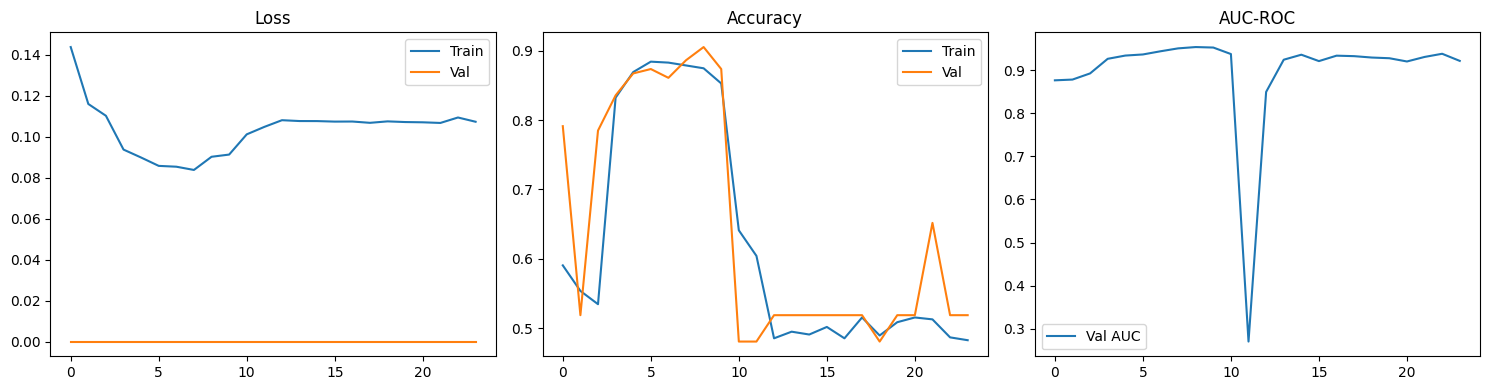


Loading best model for testing...
Best model from epoch 9 with AUC: 0.9535

Test AUC: 0.9294
Test Accuracy: 0.8726


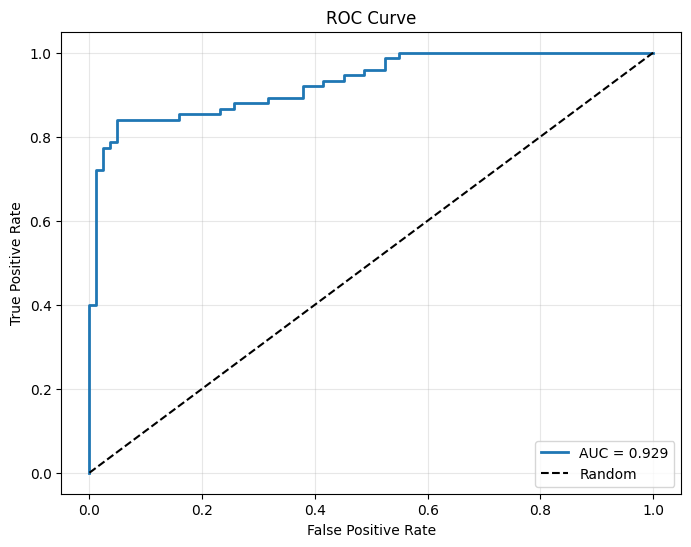

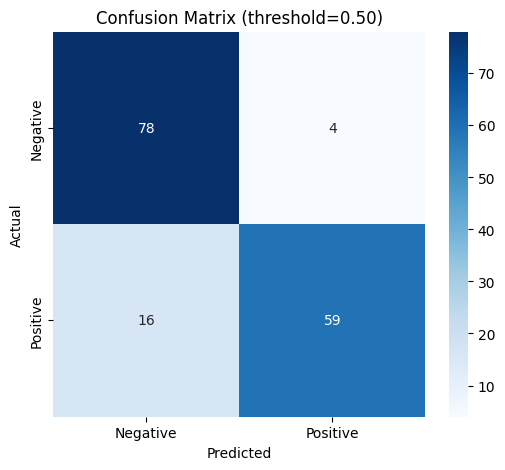

              precision    recall  f1-score   support

    Negative       0.83      0.95      0.89        82
    Positive       0.94      0.79      0.86        75

    accuracy                           0.87       157
   macro avg       0.88      0.87      0.87       157
weighted avg       0.88      0.87      0.87       157


Training Summary:
Best Validation AUC: 0.9535
Test AUC: 0.9294
Test Accuracy: 0.8726
Total Training Epochs: 9
Model Parameters: 8,276,357


In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from tqdm import tqdm
import numpy as np

# =====================================================
# Focal Loss Implementation
# =====================================================
class FocalLoss(nn.Module):
    """Focal Loss for handling hard examples"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()


# =====================================================
# Compound Loss for MIL
# =====================================================
class CompoundMILLoss(nn.Module):
    def __init__(self, 
                 use_focal=True,
                 diversity_weight=0.1,
                 sparsity_weight=0.05,
                 consistency_weight=0.1,
                 aux_weight=0.3):
        super().__init__()
        
        if use_focal:
            self.classification_loss = FocalLoss(alpha=0.25, gamma=2.0)
        else:
            self.classification_loss = nn.BCELoss()
            
        self.diversity_weight = diversity_weight
        self.sparsity_weight = sparsity_weight
        self.consistency_weight = consistency_weight
        self.aux_weight = aux_weight
        
    def attention_diversity_loss(self, attention_weights):
        """Encourage different attention heads to focus on different instances"""
        if len(attention_weights) < 2:
            return torch.tensor(0.0, device=attention_weights[0].device)
        
        A1, A2 = attention_weights[0], attention_weights[1]
        A1_flat = A1.squeeze()
        A2_flat = A2.squeeze()
        
        similarity = F.cosine_similarity(A1_flat, A2_flat, dim=0)
        return similarity.abs()
    
    def attention_sparsity_loss(self, attention_weights):
        """Encourage sparse attention"""
        loss = 0
        for A in attention_weights:
            loss += torch.sum(torch.abs(A))
        return loss / len(attention_weights)
    
    def instance_consistency_loss(self, predictions, attention_weights):
        """Penalize inconsistent predictions"""
        if len(attention_weights) == 0:
            return torch.tensor(0.0, device=predictions.device)
        
        A = attention_weights[0].squeeze()
        attention_entropy = -torch.sum(A * torch.log(A + 1e-10))
        max_entropy = np.log(A.size(0))
        normalized_entropy = attention_entropy / max_entropy
        
        return normalized_entropy
    
    def forward(self, predictions, targets, attention_weights=None, aux_preds=None):
        # Main classification loss
        cls_loss = self.classification_loss(predictions, targets)
        total_loss = cls_loss
        loss_dict = {'cls': cls_loss.item(), 'div': 0, 'sparse': 0, 'consist': 0, 'aux': 0}
        
        # Attention regularization
        if attention_weights is not None and len(attention_weights) > 0:
            div_loss = self.attention_diversity_loss(attention_weights)
            total_loss += self.diversity_weight * div_loss
            loss_dict['div'] = div_loss.item()
            
            sparse_loss = self.attention_sparsity_loss(attention_weights)
            total_loss += self.sparsity_weight * sparse_loss
            loss_dict['sparse'] = sparse_loss.item()
            
            consist_loss = self.instance_consistency_loss(predictions, attention_weights)
            total_loss += self.consistency_weight * consist_loss
            loss_dict['consist'] = consist_loss.item()
        
        # Auxiliary loss
        if aux_preds is not None:
            aux_loss = 0
            for aux_pred in aux_preds:
                aux_loss += self.classification_loss(aux_pred, targets)
            aux_loss /= len(aux_preds)
            total_loss += self.aux_weight * aux_loss
            loss_dict['aux'] = aux_loss.item()
        
        return total_loss, loss_dict


# =====================================================
# Modified Training Code
# =====================================================

# Hyper Parameters
LR = 1e-4  # Increased from 1e-5 for better convergence
BATCH_SIZE = 1  # Must be 1 for MIL
EPOCHS = 50  # Increased from 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Advanced training settings
USE_COMPOUND_LOSS = True  # Set to False to use simple BCELoss
WEIGHT_DECAY = 1e-4  # Increased from 1e-6 for better regularization
MAX_GRAD_NORM = 1.0  # Gradient clipping
WARMUP_EPOCHS = 5  # Warm restart period

# Early stopping settings
EARLY_STOPPING_PATIENCE = 15  # Increased from 5
MIN_DELTA = 1e-4  # Minimum improvement threshold

# --- Initialize Model ---
model = ComplexDualAttentionMIL(input_dim=2048).to(DEVICE)

# --- Initialize Optimizer (AdamW is better than Adam) ---
optimizer = AdamW(
    model.parameters(), 
    lr=LR, 
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# --- Learning Rate Scheduler with Warm Restarts ---
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=WARMUP_EPOCHS,
    eta_min=1e-6
)

# --- Loss Function ---
if USE_COMPOUND_LOSS:
    criterion = CompoundMILLoss(
        use_focal=True,
        diversity_weight=0.1,
        sparsity_weight=0.05,
        consistency_weight=0.1,
        aux_weight=0.3
    )
    print("Using Compound Loss with Focal Loss + Regularization")
else:
    criterion = nn.BCELoss()
    print("Using Simple BCELoss")

# --- Best Model Tracking ---
best_val_auc = 0
save_path = ROOT / "best_mil_model.pth"
no_improve_count = 0

print(f"Training on {DEVICE}...")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

# --- Training Loop ---
for epoch in range(EPOCHS):
    # ================= Training =================
    model.train()
    train_loss = 0
    train_correct = 0
    
    # Track loss components
    loss_components = {'cls': 0, 'div': 0, 'sparse': 0, 'consist': 0, 'aux': 0}
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for bag, label in pbar:
        bag = bag.to(DEVICE)
        label = label.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Forward pass with auxiliary outputs
        try:
            output, attention_weights, aux_preds = model(bag, return_aux=True)
        except:
            # Fallback if model doesn't support return_aux
            output, attention_weights = model(bag)
            aux_preds = None
        
        # Compute loss
        if USE_COMPOUND_LOSS:
            loss, loss_dict = criterion(
                output, 
                label, 
                attention_weights=attention_weights,
                aux_preds=aux_preds
            )
            # Accumulate loss components
            for key in loss_dict:
                loss_components[key] += loss_dict[key]
        else:
            loss = criterion(output, label)
        
        # Backward pass with gradient clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        
        # Metrics
        train_loss += loss.item()
        pred = (output > 0.5).float()
        train_correct += (pred == label).sum().item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Update learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / len(train_loader)
    
    # Average loss components
    for key in loss_components:
        loss_components[key] /= len(train_loader)
    
    # ================= Validation =================
    model.eval()
    val_result = evaluate_model(model, val_loader, DEVICE)
    
    # Calculate Validation Accuracy
    val_preds = (val_result['probs'] >= 0.5).astype(int)
    val_acc = (val_preds == val_result['labels']).mean()
    
    # Log History
    history.log(avg_train_loss, avg_train_acc, 0, val_acc, val_result['auc'])
    
    # Print Results
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Acc: {avg_train_acc:.4f}")
    print(f"  Val Acc: {val_acc:.4f} | AUC: {val_result['auc']:.4f}")
    
    if USE_COMPOUND_LOSS:
        print(f"  Loss Components: cls={loss_components['cls']:.4f}, "
              f"div={loss_components['div']:.4f}, "
              f"sparse={loss_components['sparse']:.4f}, "
              f"consist={loss_components['consist']:.4f}, "
              f"aux={loss_components['aux']:.4f}")
    
    print(f"  Learning Rate: {current_lr:.6f}")
    
    # Save Best Model with improvement threshold
    if val_result['auc'] > best_val_auc + MIN_DELTA:
        best_val_auc = val_result['auc']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_auc': best_val_auc,
        }, save_path)
        print(f"  >>> Best AUC! Model saved to {save_path}")
        no_improve_count = 0
    else:
        no_improve_count += 1
        print(f"  >>> No improvement ({no_improve_count}/{EARLY_STOPPING_PATIENCE})")
    
    # Early Stopping
    if no_improve_count >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered!")
        break

print("\nTraining Finished!")
history.plot()

# ================= Test =================
print("\nLoading best model for testing...")
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model from epoch {checkpoint['epoch']+1} with AUC: {checkpoint['best_val_auc']:.4f}")

test_result = evaluate_model(model, test_loader, DEVICE)
print(f"\nTest AUC: {test_result['auc']:.4f}")

# Get test accuracy
test_preds = (test_result['probs'] >= 0.5).astype(int)
test_acc = (test_preds == test_result['labels']).mean()
print(f"Test Accuracy: {test_acc:.4f}")

plot_roc_curve(test_result)
plot_confusion_matrix(test_result, threshold=0.5)

# ================= Additional Analysis =================
print("\n" + "="*50)
print("Training Summary:")
print("="*50)
print(f"Best Validation AUC: {checkpoint['best_val_auc']:.4f}")
print(f"Test AUC: {test_result['auc']:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Total Training Epochs: {checkpoint['epoch']+1}")
print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("="*50)

In [ ]:
def generate_all_heatmaps(model, test_loader, output_dir, target=10, device=DEVICE):
    '''
    對 test_loader 中的所有樣本產生 Attention Heatmap 並儲存
    
    Args:
        model: 訓練好的 MIL 模型
        test_loader: 測試資料的 DataLoader
        output_dir: 輸出資料夾路徑
    '''
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    model.eval()
    num = 0
    for idx, (bag_tensor, label) in enumerate(test_loader):
        if num < target:
            num += 1
        else:
            break
        pt_path, true_label = test_loader.dataset.data_list[idx]
        bag_name = pt_path.stem  
        
        is_positive = "positive" in str(pt_path)
        label_str = "pos" if is_positive else "neg"
        
        if is_positive:
            original_bag_dir = DATASET_POSITIVE_TILED_DIR / bag_name
            raw_image_path = RAW_POSITIVE_IMAGES_ROOT / f"{bag_name}.png"
        else:
            original_bag_dir = DATASET_NEGATIVE_TILED_DIR / bag_name
            raw_image_path = RAW_NEGATIVE_IMAGES_ROOT / f"{bag_name}.png"
        
        for ext in ['.png']:
            candidate = raw_image_path.with_suffix(ext)
            if candidate.exists():
                raw_image_path = candidate
                break
        
        coords_file = original_bag_dir / "coords.csv"
        if not coords_file.exists():
            print(f"⚠️ Skip {bag_name}: coords.csv not found")
            continue
        
        coords_df = pd.read_csv(coords_file)
        patch_coords = list(zip(coords_df['x'], coords_df['y']))
        

        with torch.no_grad():
            bag_tensor = bag_tensor.to(device)
            prob, attention = model(bag_tensor)
        
        # === FIX START: Handle tuple return from ComplexDualAttentionMIL ===
        if isinstance(attention, tuple):
            # Average the attention maps from the two branches (A1, A2)
            attention = (attention[0] + attention[1]) / 2
        # === FIX END ===

        attention = attention.squeeze().cpu().numpy()
        attention = attention ** 0.5
        pred_prob = prob.item()
        pred_label = "pos" if pred_prob > 0.5 else "neg"
        
        # 讀取原圖
        if not raw_image_path.exists():
            print(f"⚠️ Skip {bag_name}: raw image not found")
            continue
            
        original_img = np.array(Image.open(raw_image_path).convert('RGB'))
        h, w = original_img.shape[:2]
        
        # 建立 heatmap
        heatmap = np.zeros((h, w), dtype=np.float32)
        count_map = np.zeros((h, w), dtype=np.float32)
        for i, (x, y) in enumerate(patch_coords):
            if i < len(attention):
                heatmap[y:y+SLICE_HEIGHT, x:x+SLICE_WIDTH] += attention[i]
                count_map[y:y+SLICE_HEIGHT, x:x+SLICE_WIDTH] += 1
        
        # Average the heatmap values where overlap occurs
        mask = count_map > 0
        heatmap[mask] /= count_map[mask]
        
        # 正規化
        if heatmap.max() > heatmap.min():
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
        
        # 畫圖
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(original_img)
        axes[0].set_title('Original')
        axes[0].axis('off')
        
        axes[1].imshow(heatmap, cmap='jet')
        axes[1].set_title('Attention Heatmap')
        axes[1].axis('off')
        
        axes[2].imshow(original_img)
        axes[2].imshow(heatmap, cmap='jet', alpha=0.5)
        axes[2].set_title(f'Overlay\nTrue: {label_str} | Pred: {pred_label} ({pred_prob:.2f})')
        axes[2].axis('off')
        
        plt.tight_layout()
        
        # 儲存
        save_name = f"{bag_name}_true-{label_str}_pred-{pred_label}_{pred_prob:.2f}.png"
        plt.savefig(output_path / save_name, dpi=100, bbox_inches='tight')
        plt.close()
        
        print(f"✓ [{idx+1}/{len(test_loader)}] Saved: {save_name}")
    
    print(f"\n🎉 Done! All heatmaps saved to: {output_path}")

In [ ]:
model = 
generate_all_heatmaps(model, test_loader, ROOT / "heatmaps_test")

✓ [1/157] Saved: 398_true-neg_pred-neg_0.19.png
✓ [2/157] Saved: 412_true-pos_pred-pos_0.87.png
✓ [3/157] Saved: 145_true-neg_pred-neg_0.18.png
✓ [4/157] Saved: 203_true-pos_pred-pos_0.87.png
✓ [5/157] Saved: 74_true-pos_pred-pos_0.87.png
✓ [6/157] Saved: 198_true-pos_pred-neg_0.18.png
✓ [7/157] Saved: 80_true-neg_pred-neg_0.18.png
✓ [8/157] Saved: 153_true-pos_pred-neg_0.19.png
✓ [9/157] Saved: 324_true-neg_pred-neg_0.18.png
✓ [10/157] Saved: 21_true-neg_pred-neg_0.18.png

🎉 Done! All heatmaps saved to: /home/liang/workdir/NCKU-ML-25Fall/Final_Project/heatmaps_test
